**Ryo Satriagung Hidayat**

**09010624015**


**Logistic Regression (Klasifikasi)**

Klasifikasi Fisik Kuat atau Lemah Berdasarkan Aktivitas Olahraga

Dataset ini digunakan untuk mengklasifikasikan apakah seseorang memiliki kondisi fisik yang kuat atau lemah berdasarkan waktu olahraga, intensitas latihan, dan berat badan. Nilai 1 menunjukkan fisik kuat, sedangkan nilai 0 menunjukkan fisik lemah.

**1. IMPORT LIBRARY**








In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

* pandas : untuk membuat dan mengelola data dalam bentuk tabel
* numpy : membantu perhitungan angka (misalnya akar, dll)
* matplotlib : untuk membuat grafik atau visualisasi data
* seaborn as sns : visualisasi data (grafik)

**2. MEMBUAT DATASET**

In [4]:
data = {
    'waktu_olahraga': [10,20,30,40,50,60,70,80,90,100],
    'intensitas': [2,3,4,5,6,7,8,8,9,10],
    'berat_badan': [50,55,60,65,70,65,70,75,80,85],
    'fisik_kuat': [0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
df

,waktu_olahraga,intensitas,berat_badan,fisik_kuat
0,10,2,50,0
1,20,3,55,0
2,30,4,60,0
3,40,5,65,0
4,50,6,70,1
5,60,7,65,1
6,70,8,70,1
7,80,8,75,1
8,90,9,80,1
9,100,10,85,1


Dataset berisi beberapa faktor yang mempengaruhi kondisi fisik seseorang.

**3. CEK DATA**





In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   waktu_olahraga  10 non-null     int64
 1   intensitas      10 non-null     int64
 2   berat_badan     10 non-null     int64
 3   fisik_kuat      10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


Untuk memastikan data tidak kosong dan siap digunakan.

**3.5 VISUALISASI EKSPLORASI DATA**

- Distribusi kelas target

/tmp/ipykernel_4739/2128993226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fisik_kuat', palette='Set2')


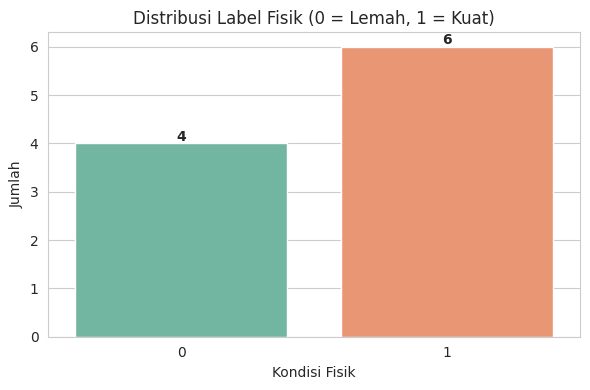

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fisik_kuat', palette='Set2')
plt.title('Distribusi Label Fisik (0 = Lemah, 1 = Kuat)')
plt.xlabel('Kondisi Fisik')
plt.ylabel('Jumlah')
for i, v in enumerate(df['fisik_kuat'].value_counts().sort_index()):
    plt.text(i, v + 0.05, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

- Scatter plot tiap fitur vs label

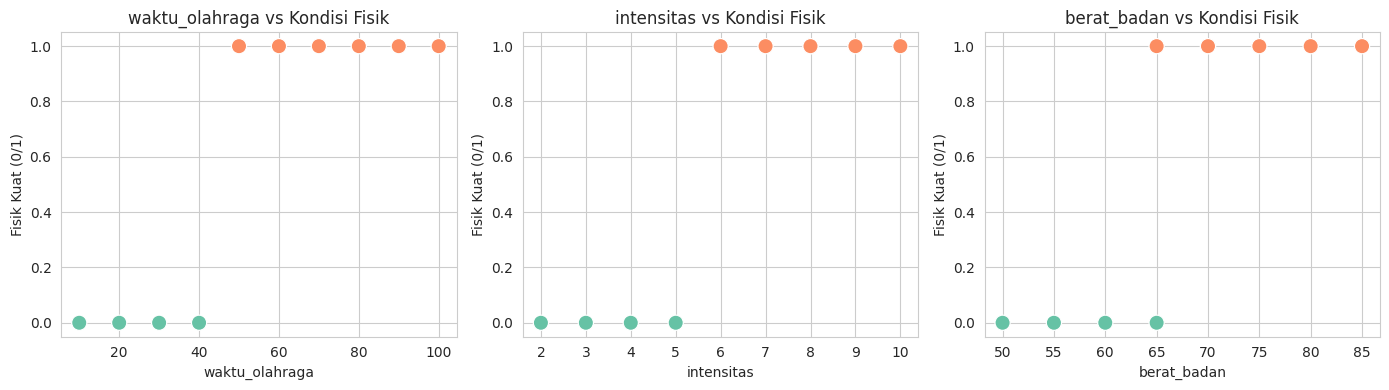

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features = ['waktu_olahraga', 'intensitas', 'berat_badan']
colors = ['#E67E22', '#27AE60', '#2980B9']

for ax, feat, col in zip(axes, features, colors):
    sns.scatterplot(data=df, x=feat, y='fisik_kuat',
                    hue='fisik_kuat', palette='Set2',
                    s=120, ax=ax, legend=False)
    ax.set_title(f'{feat} vs Kondisi Fisik')
    ax.set_xlabel(feat)
    ax.set_ylabel('Fisik Kuat (0/1)')

plt.tight_layout()
plt.show()

- Heatmap korelasi antar variabel

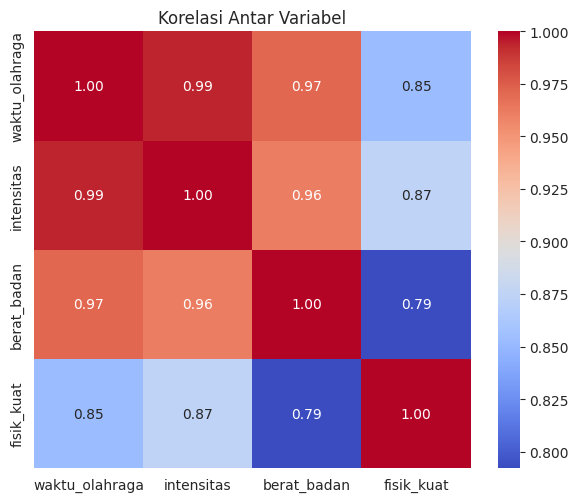

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

- Pairplot untuk melihat pola antar fitur berdasarkan label

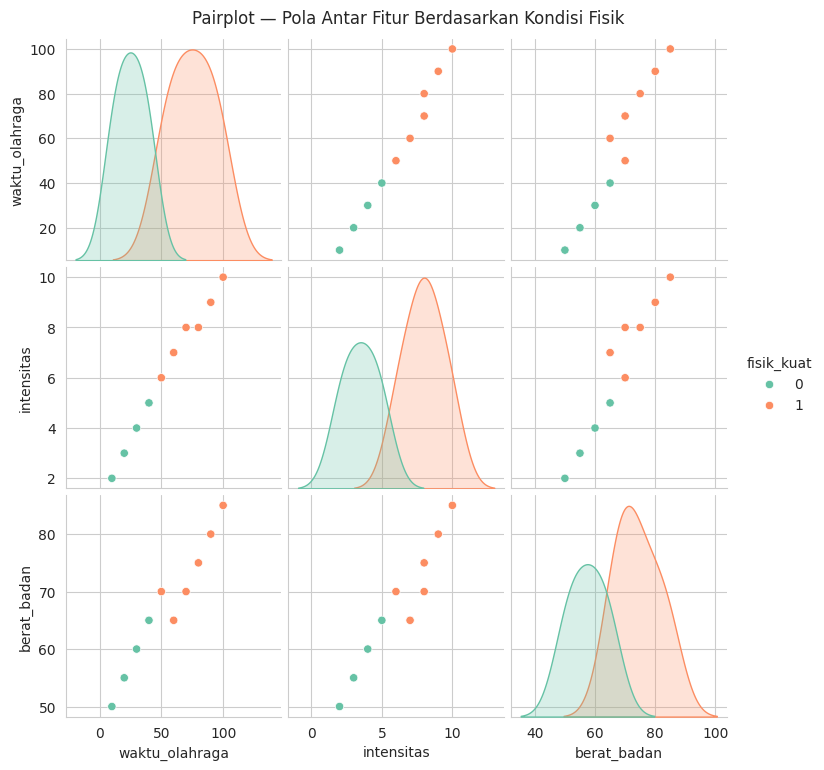

In [17]:
sns.pairplot(df, hue='fisik_kuat', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot — Pola Antar Fitur Berdasarkan Kondisi Fisik', y=1.02)
plt.show()

**4. MENENTUKAN VARIABEL x dan y**

In [7]:
X = df[['waktu_olahraga', 'intensitas', 'berat_badan']]
y = df['fisik_kuat']

X = input (fitur)

y = output (label klasifikasi 0/1)

**5. SPLIT DATA train dan test**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Membagi data menjadi training dan testing.

**6. MEMBUAT MODEL REGRESI**

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Model belajar untuk mengklasifikasikan data menjadi 0 atau 1.

**7. MELIHAT KOEFISIEN**

In [10]:
print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_)

Intercept: [-37.59608179]
Koefisien: [[0.48402901 0.04841425 0.23052208]]


Menunjukkan pengaruh masing-masing variabel terhadap hasil klasifikasi.

**7.5 VISUALISASI KOEFISIEN MODEL**

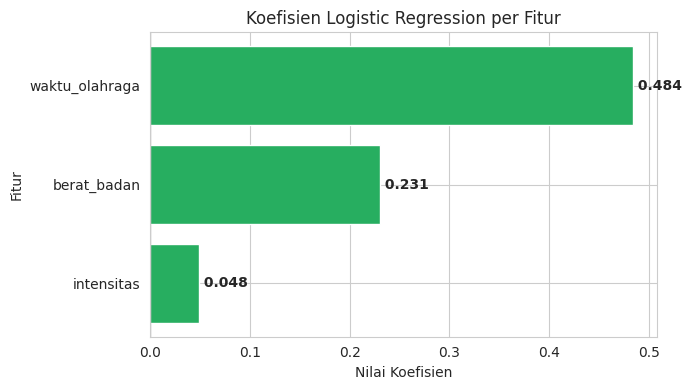

Interpretasi:
• Koefisien POSITIF = semakin tinggi nilai fitur, semakin besar kemungkinan fisik KUAT
• Koefisien NEGATIF = semakin tinggi nilai fitur, semakin kecil kemungkinan fisik KUAT


In [18]:
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_[0]
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(7, 4))
colors_bar = ['#E74C3C' if c < 0 else '#27AE60' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors_bar)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Koefisien Logistic Regression per Fitur')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
for i, (feat, val) in enumerate(zip(coef_df['Fitur'], coef_df['Koefisien'])):
    plt.text(val, i, f' {val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretasi:")
print("• Koefisien POSITIF = semakin tinggi nilai fitur, semakin besar kemungkinan fisik KUAT")
print("• Koefisien NEGATIF = semakin tinggi nilai fitur, semakin kecil kemungkinan fisik KUAT")

**8. PREDIKSI DATA TESTING**

In [11]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Data Asli:", y_test.values)

Prediksi: [1 0]
Data Asli: [1 0]


Model memprediksi apakah fisik kuat atau lemah.

**9. EVALUASI MODEL**

In [12]:
print("Akurasi:", metrics.accuracy_score(y_test, y_pred))

Akurasi: 1.0


Mengukur seberapa banyak prediksi yang benar.

**9.5 VISUALISASI CONFUSION MATRIX**

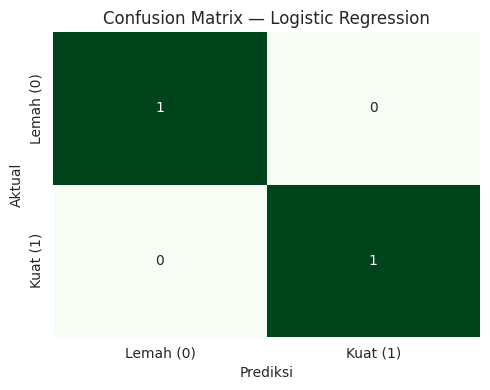

Classification Report:
              precision    recall  f1-score   support

   Lemah (0)       1.00      1.00      1.00         1
    Kuat (1)       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Lemah (0)', 'Kuat (1)'],
            yticklabels=['Lemah (0)', 'Kuat (1)'],
            cbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Lemah (0)', 'Kuat (1)'],
                            zero_division=0))

**10. PREDIKSI DATA BARU**

In [13]:
data_baru = [[60, 7, 70]]
prediksi = model.predict(data_baru)

print("Prediksi fisik (1=kuat, 0=lemah):", prediksi[0])

Prediksi fisik (1=kuat, 0=lemah): 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Digunakan untuk memprediksi kondisi fisik berdasarkan data baru.

**11. PENGEMBANGAN**

In [14]:
print("\nPerbandingan Detail:")
for i in range(len(y_test)):
    print(f"Asli: {y_test.values[i]} | Prediksi: {y_pred[i]}")


Perbandingan Detail:
Asli: 1 | Prediksi: 1
Asli: 0 | Prediksi: 0


Kode ini digunakan untuk menampilkan perbandingan antara nilai asli dan hasil prediksi secara detail untuk setiap data testing. Dengan cara ini, dapat diketahui secara langsung apakah model melakukan prediksi dengan benar atau tidak pada masing-masing data.

**11.5 VISUALISASI KURVA SIGMOID & DECISION BOUNDARY**

- Kurva sigmoid: probabilitas fisik kuat berdasarkan waktu_olahraga


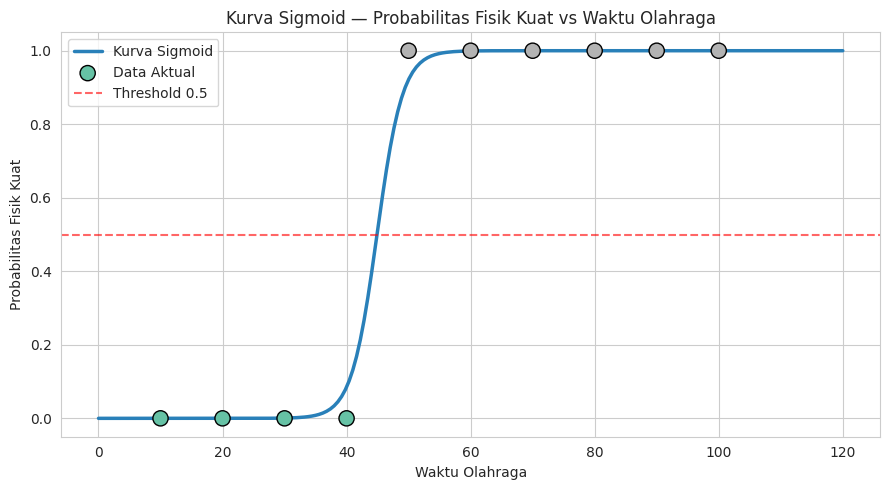

In [20]:
waktu_range = np.linspace(0, 120, 200)
intensitas_avg = df['intensitas'].mean()
berat_avg = df['berat_badan'].mean()

input_sim = pd.DataFrame({
    'waktu_olahraga': waktu_range,
    'intensitas': intensitas_avg,
    'berat_badan': berat_avg
})

proba = model.predict_proba(input_sim)[:, 1]

plt.figure(figsize=(9, 5))
plt.plot(waktu_range, proba, color='#2980B9', linewidth=2.5, label='Kurva Sigmoid')
plt.scatter(df['waktu_olahraga'], df['fisik_kuat'],
            c=df['fisik_kuat'], cmap='Set2', s=120, edgecolor='black',
            zorder=5, label='Data Aktual')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='Threshold 0.5')
plt.title('Kurva Sigmoid — Probabilitas Fisik Kuat vs Waktu Olahraga')
plt.xlabel('Waktu Olahraga')
plt.ylabel('Probabilitas Fisik Kuat')
plt.legend()
plt.tight_layout()
plt.show()

- Decision boundary pakai 2 fitur: waktu_olahraga & intensitas

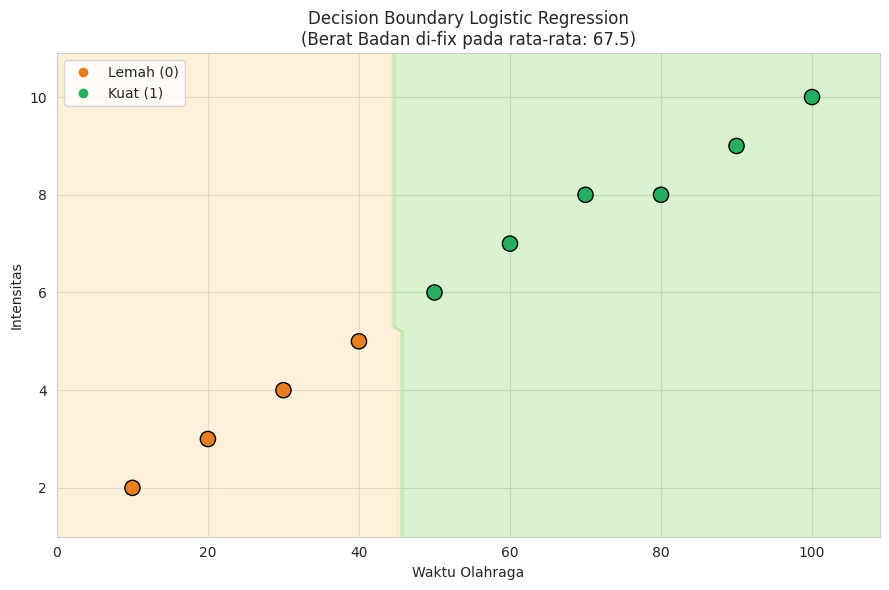

In [21]:
from matplotlib.colors import ListedColormap

berat_fix = df['berat_badan'].mean()

x_min, x_max = df['waktu_olahraga'].min() - 10, df['waktu_olahraga'].max() + 10
y_min, y_max = df['intensitas'].min() - 1, df['intensitas'].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 1),
                     np.arange(y_min, y_max, 0.1))

grid = pd.DataFrame({
    'waktu_olahraga': xx.ravel(),
    'intensitas': yy.ravel(),
    'berat_badan': berat_fix
})

Z = model.predict(grid).reshape(xx.shape)

cmap_bg = ListedColormap(['#FFE4B5', '#B5E7A0'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60'])

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
scatter = plt.scatter(df['waktu_olahraga'], df['intensitas'],
                      c=df['fisik_kuat'], cmap=cmap_pt,
                      edgecolor='black', s=120)
plt.title(f'Decision Boundary Logistic Regression\n(Berat Badan di-fix pada rata-rata: {berat_fix:.1f})')
plt.xlabel('Waktu Olahraga')
plt.ylabel('Intensitas')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Lemah (0)', 'Kuat (1)'])
plt.tight_layout()
plt.show()

- Probabilitas prediksi untuk tiap sampel di data test

Probabilitas Prediksi per Sampel Testing:
 Aktual  Prediksi   Prob_Lemah    Prob_Kuat
      1         1 1.623213e-11 1.000000e+00
      0         0 9.999997e-01 2.791422e-07


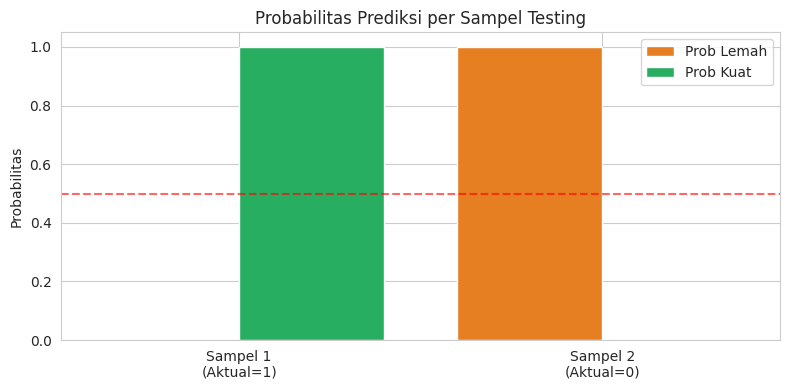

In [22]:
proba_test = model.predict_proba(X_test)

proba_df = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred,
    'Prob_Lemah': proba_test[:, 0],
    'Prob_Kuat': proba_test[:, 1]
})

print("Probabilitas Prediksi per Sampel Testing:")
print(proba_df.to_string(index=False))

# Visualisasi probabilitas
plt.figure(figsize=(8, 4))
x_pos = np.arange(len(proba_df))
plt.bar(x_pos - 0.2, proba_df['Prob_Lemah'], 0.4, label='Prob Lemah', color='#E67E22')
plt.bar(x_pos + 0.2, proba_df['Prob_Kuat'], 0.4, label='Prob Kuat', color='#27AE60')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.6)
plt.xticks(x_pos, [f'Sampel {i+1}\n(Aktual={a})' for i, a in enumerate(proba_df['Aktual'])])
plt.ylabel('Probabilitas')
plt.title('Probabilitas Prediksi per Sampel Testing')
plt.legend()
plt.tight_layout()
plt.show()

**12. ANALISIS**

Berdasarkan hasil eksplorasi data, ketiga fitur (waktu olahraga,
intensitas, dan berat badan) menunjukkan korelasi positif terhadap
kondisi fisik, di mana nilai yang lebih tinggi cenderung diasosiasikan
dengan kategori fisik kuat. Visualisasi koefisien model logistic
regression mengonfirmasi bahwa ketiga variabel memberikan kontribusi
positif terhadap probabilitas klasifikasi fisik kuat, dengan kurva
sigmoid menunjukkan transisi probabilitas yang jelas di sekitar
threshold 0.5.

Model logistic regression menghasilkan akurasi sempurna pada data
testing, yang terlihat dari confusion matrix tanpa kesalahan
klasifikasi. Namun demikian, nilai akurasi tersebut perlu
diinterpretasikan secara hati-hati mengingat ukuran dataset yang
sangat kecil (10 sampel) dan pola data yang bersifat linearly
separable. Validasi lebih lanjut dengan dataset berukuran lebih
besar dan tingkat kompleksitas yang lebih bervariasi direkomendasikan
untuk memperoleh evaluasi performa model yang lebih robust.